# 1. import library

In [2]:
# ============================================================
# 1. IMPORT LIBRARY
# ============================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from scipy.sparse import hstack

# 2. load data yang telah di proses

In [3]:
# ============================================================
# 2. LOAD DATA
# ============================================================
df = pd.read_csv('../data/processed/data_kriminal_processed.csv')

print("Distribusi kelas PERKARA:")
print(df['PERKARA'].value_counts())
print("\nPersentase:")
print(df['PERKARA'].value_counts(normalize=True) * 100)
df.info()

Distribusi kelas PERKARA:
PERKARA
Pencurian       224
Penganiayaan    110
Penipuan        109
Perusakan        89
Narkoba          60
Name: count, dtype: int64

Persentase:
PERKARA
Pencurian       37.837838
Penganiayaan    18.581081
Penipuan        18.412162
Perusakan       15.033784
Narkoba         10.135135
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 592 entries, 0 to 591
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   NO_LAPORAN     592 non-null    object
 1   TGL_LAPORAN    592 non-null    object
 2   PERKARA        592 non-null    object
 3   PELAPOR        592 non-null    object
 4   TERLAPOR       592 non-null    object
 5   TKP            592 non-null    object
 6   DESA           592 non-null    object
 7   BARANG BUKTI   592 non-null    object
 8   BB_final_text  435 non-null    object
 9   MO             592 non-null    object
 10  MO_final_text  592 non-null   

# 3. tentukan fitur dan target

In [4]:
# ============================================================
# 3. PERSIAPAN FITUR & TARGET (FITUR TERPISAH)
# ============================================================
print("="*70)
print("TAHAP 1: PERSIAPAN DATA")
print("="*70)

X_mo = df['MO_final_text'].fillna('').astype(str)
X_bb = df['BB_final_text'].fillna('').astype(str)
y = df['PERKARA']

print(f"Jumlah sampel: {len(df)}")
print(f"Jumlah kelas: {y.nunique()}")
print(f"Distribusi kelas:\n{y.value_counts()}")
print(f"\nContoh MO_final_text:\n{X_mo.iloc[0][:200]}...")
print(f"\nContoh BB_final_text:\n{X_bb.iloc[0][:200]}...")

TAHAP 1: PERSIAPAN DATA
Jumlah sampel: 592
Jumlah kelas: 5
Distribusi kelas:
PERKARA
Pencurian       224
Penganiayaan    110
Penipuan        109
Perusakan        89
Narkoba          60
Name: count, dtype: int64

Contoh MO_final_text:
pelaku singgung tatap korban papas pukul wajah korban tangan kosong...

Contoh BB_final_text:
hasil visum repertum...


# 4. SPLIT DATA

In [5]:
# ============================================================
# 4. SPLIT DATA & TF-IDF UNTUK 4 SKENARIO
# ============================================================
SPLITS = [0.4, 0.3, 0.2, 0.1]  # 60:40, 70:30, 80:20, 90:10

# Dictionary untuk menyimpan hasil tiap split
hasil_split = {}

for test_size in SPLITS:
    train_pct = int((1 - test_size) * 100)
    test_pct = int(test_size * 100)
    split_name = f"{train_pct}_{test_pct}"
    
    print("\n" + "="*70)
    print(f"TAHAP 2: SPLIT DATA {split_name} (Data Masih Berupa Teks)")
    print("="*70)
    
    # --- 4.1 Stratified Split ---
    X_mo_train, X_mo_test, X_bb_train, X_bb_test, y_train, y_test = train_test_split(
        X_mo, X_bb, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )
    
    print(f"Training set: {len(X_mo_train)} sampel ({train_pct}%)")
    print(f"Testing set:  {len(X_mo_test)} sampel ({test_pct}%)")
    print("\nDistribusi kelas TRAIN:")
    print(y_train.value_counts())
    print("\nDistribusi kelas TEST:")
    print(y_test.value_counts())
    
    # --- 4.2 Inisialisasi TF-IDF Vectorizer (default) ---
    print("\n" + "-"*60)
    print("TAHAP 3: INISIALISASI TF-IDF VECTORIZER")
    print("-"*60)
    
    vectorizer_mo = TfidfVectorizer()
    vectorizer_bb = TfidfVectorizer()
    
    # --- 4.3 Fit TF-IDF pada Training Set ---
    print("\n" + "-"*60)
    print("TAHAP 4: FIT TF-IDF PADA DATA TRAINING (HANYA TRAINING!)")
    print("-"*60)
    
    X_mo_train_tfidf = vectorizer_mo.fit_transform(X_mo_train)
    X_bb_train_tfidf = vectorizer_bb.fit_transform(X_bb_train)
    
    print(f"✅ MO Training TF-IDF shape: {X_mo_train_tfidf.shape}")
    print(f"   - Fitur (vocabulary): {X_mo_train_tfidf.shape[1]}")
    print(f"   - Non-zero: {X_mo_train_tfidf.nnz}")
    
    print(f"\n✅ BB Training TF-IDF shape: {X_bb_train_tfidf.shape}")
    print(f"   - Fitur (vocabulary): {X_bb_train_tfidf.shape[1]}")
    print(f"   - Non-zero: {X_bb_train_tfidf.nnz}")
    
    # --- 4.4 Transform Test Set ---
    print("\n" + "-"*60)
    print("TAHAP 5: TRANSFORM DATA TESTING (HANYA .transform()!)")
    print("-"*60)
    
    X_mo_test_tfidf = vectorizer_mo.transform(X_mo_test)
    X_bb_test_tfidf = vectorizer_bb.transform(X_bb_test)
    
    print(f"✅ MO Testing TF-IDF shape: {X_mo_test_tfidf.shape}")
    print(f"✅ BB Testing TF-IDF shape: {X_bb_test_tfidf.shape}")
    
    # Verifikasi jumlah fitur sama
    print(f"\n🔍 Verifikasi jumlah fitur:")
    print(f"   MO Train features: {X_mo_train_tfidf.shape[1]}")
    print(f"   MO Test features:  {X_mo_test_tfidf.shape[1]} → SAMA ✓")
    print(f"   BB Train features: {X_bb_train_tfidf.shape[1]}")
    print(f"   BB Test features:  {X_bb_test_tfidf.shape[1]} → SAMA ✓")
    
    # --- 4.5 Gabungkan Fitur MO dan BB ---
    print("\n" + "-"*60)
    print("TAHAP 6: GABUNGKAN FITUR MO DAN BB")
    print("-"*60)
    
    X_train_combined = hstack([X_mo_train_tfidf, X_bb_train_tfidf])
    X_test_combined = hstack([X_mo_test_tfidf, X_bb_test_tfidf])
    
    print(f"✅ Training data shape setelah digabung: {X_train_combined.shape}")
    print(f"   - Fitur MO: {X_mo_train_tfidf.shape[1]}")
    print(f"   - Fitur BB: {X_bb_train_tfidf.shape[1]}")
    print(f"   - Total fitur: {X_train_combined.shape[1]}")
    print(f"\n✅ Testing data shape setelah digabung: {X_test_combined.shape}")
    
    # Cek sparsity
    sparsity_train = 1 - (X_train_combined.nnz / (X_train_combined.shape[0] * X_train_combined.shape[1]))
    sparsity_test  = 1 - (X_test_combined.nnz / (X_test_combined.shape[0] * X_test_combined.shape[1]))
    print(f"\n📊 Sparsity (persentase nol):")
    print(f"   Training: {sparsity_train:.2%}")
    print(f"   Testing:  {sparsity_test:.2%}")
    
    # --- Simpan hasil ke dictionary ---
    hasil_split[split_name] = {
        'vectorizer_mo': vectorizer_mo,
        'vectorizer_bb': vectorizer_bb,
        'X_train': X_train_combined,
        'X_test': X_test_combined,
        'y_train': y_train,
        'y_test': y_test,
        'X_mo_train_tfidf': X_mo_train_tfidf,
        'X_bb_train_tfidf': X_bb_train_tfidf,
        'n_mo_features': X_mo_train_tfidf.shape[1],
        'n_bb_features': X_bb_train_tfidf.shape[1],
        'total_features': X_train_combined.shape[1]
    }
    
    print(f"\n🎯 Split {split_name} SELESAI!")
    print("="*70)


TAHAP 2: SPLIT DATA 60_40 (Data Masih Berupa Teks)
Training set: 355 sampel (60%)
Testing set:  237 sampel (40%)

Distribusi kelas TRAIN:
PERKARA
Pencurian       134
Penganiayaan     66
Penipuan         65
Perusakan        54
Narkoba          36
Name: count, dtype: int64

Distribusi kelas TEST:
PERKARA
Pencurian       90
Penipuan        44
Penganiayaan    44
Perusakan       35
Narkoba         24
Name: count, dtype: int64

------------------------------------------------------------
TAHAP 3: INISIALISASI TF-IDF VECTORIZER
------------------------------------------------------------

------------------------------------------------------------
TAHAP 4: FIT TF-IDF PADA DATA TRAINING (HANYA TRAINING!)
------------------------------------------------------------
✅ MO Training TF-IDF shape: (355, 738)
   - Fitur (vocabulary): 738
   - Non-zero: 3895

✅ BB Training TF-IDF shape: (355, 184)
   - Fitur (vocabulary): 184
   - Non-zero: 849

------------------------------------------------------

# 5. RINGKASAN PERBANDINGAN KEEMPAT SPLIT

In [6]:
# ============================================================
# 5. RINGKASAN PERBANDINGAN KEEMPAT SPLIT
# ============================================================
print("\n" + "="*70)
print("📊 RINGKASAN PERBANDINGAN KEEMPAT SPLIT")
print("="*70)

ringkasan = []
for split_name, hasil in hasil_split.items():
    ringkasan.append({
        'Split': split_name,
        'Train Size': hasil['X_train'].shape[0],
        'Test Size': hasil['X_test'].shape[0],
        'MO Features': hasil['n_mo_features'],
        'BB Features': hasil['n_bb_features'],
        'Total Features': hasil['total_features']
    })

df_ringkasan = pd.DataFrame(ringkasan)
print(df_ringkasan.to_string(index=False))


📊 RINGKASAN PERBANDINGAN KEEMPAT SPLIT
Split  Train Size  Test Size  MO Features  BB Features  Total Features
60_40         355        237          738          184             922
70_30         414        178          789          203             992
80_20         473        119          848          226            1074
90_10         532         60          883          230            1113


# 6. EDA: MEAN TF-IDF GLOBAL (menggunakan split 80:20 sebagai contoh)

In [7]:
# ============================================================
# 6. EDA: MEAN TF-IDF GLOBAL (menggunakan split 80:20 sebagai contoh)
# ============================================================
print("\n" + "="*70)
print("TAHAP 7: EKSPLORASI KATA PENTING (Mean TF-IDF)")
print("="*70)

# Gunakan split 80:20 untuk EDA (atau bisa ganti dengan split lain)
split_eda = '80_20'
X_train_eda = hasil_split[split_eda]['X_train']
vectorizer_mo_eda = hasil_split[split_eda]['vectorizer_mo']
vectorizer_bb_eda = hasil_split[split_eda]['vectorizer_bb']

# Gabungkan feature names dari kedua vectorizer
mo_features = vectorizer_mo_eda.get_feature_names_out()
bb_features = vectorizer_bb_eda.get_feature_names_out()
all_features = np.concatenate([mo_features, bb_features])

# Hitung rata-rata TF-IDF per fitur pada training set
mean_tfidf_values = X_train_eda.mean(axis=0).A1  # rata-rata kolom (dense array)
mean_series = pd.Series(mean_tfidf_values, index=all_features).sort_values(ascending=False)

print(f"Top 20 kata dengan rata-rata TF-IDF tertinggi (global) - Split {split_eda}:")
print(mean_series.head(20).round(4))


TAHAP 7: EKSPLORASI KATA PENTING (Mean TF-IDF)
Top 20 kata dengan rata-rata TF-IDF tertinggi (global) - Split 80_20:
korban       0.0901
pelaku       0.0892
ambil        0.0505
kwitansi     0.0464
transfer     0.0453
motor        0.0445
motor        0.0432
uang         0.0421
tunai        0.0403
rumah        0.0397
sepeda       0.0395
rusak        0.0373
visum        0.0369
hasil        0.0369
uang         0.0357
milik        0.0354
kunci        0.0346
repertum     0.0345
handphone    0.0291
emas         0.0289
dtype: float64


# 7. EDA: KATA KHAS PER KELAS (dengan membuat dokumen per kelas)

In [8]:
# ============================================================
# 7. EDA: KATA KHAS PER KELAS (dengan membuat dokumen per kelas)
# ============================================================
print("\n" + "="*70)
print("TAHAP 8: EKSPLORASI KATA KHAS PER JENIS PERKARA")
print("="*70)

# Buat kolom gabungan sementara (hanya untuk EDA, tidak untuk modeling)
df['TEXT_COMBINED'] = df['MO_final_text'].fillna('') + ' ' + df['BB_final_text'].fillna('')

# Buat satu dokumen per kelas (gabungkan semua teks dalam kelas)
kelas_docs = df.groupby('PERKARA')['TEXT_COMBINED'].apply(lambda x: ' '.join(x))

# Vectorize per kelas
tfidf_kelas = TfidfVectorizer()
X_kelas = tfidf_kelas.fit_transform(kelas_docs)
feature_names_kelas = tfidf_kelas.get_feature_names_out()

tfidf_class_df = pd.DataFrame(
    X_kelas.toarray(),
    index=kelas_docs.index,
    columns=feature_names_kelas
).round(4)

print("TF-IDF per kelas (sampel):")
print(tfidf_class_df.head())

# Tampilkan top 10 kata per kelas
print("\n🔍 Top 10 kata per kelas:")
for perkara in tfidf_class_df.index:
    top_words = tfidf_class_df.loc[perkara].sort_values(ascending=False).head(10)
    print(f"\n=== {perkara} ===")
    print(top_words)


TAHAP 8: EKSPLORASI KATA KHAS PER JENIS PERKARA
TF-IDF per kelas (sampel):
                 abu    acak   acara   acer   ada   admin  administrasi  \
PERKARA                                                                   
Narkoba       0.0000  0.0000  0.0000  0.000  0.01  0.0000        0.0000   
Pencurian     0.0063  0.0316  0.0000  0.038  0.00  0.0000        0.0000   
Penganiayaan  0.0000  0.0000  0.0000  0.000  0.00  0.0000        0.0000   
Penipuan      0.0000  0.0000  0.0000  0.000  0.00  0.0062        0.0062   
Perusakan     0.0000  0.0000  0.0175  0.000  0.00  0.0000        0.0000   

                 adu    agen     air  ...  website  whatsapp    wifi  wilayah  \
PERKARA                               ...                                       
Narkoba       0.0000  0.0000  0.0067  ...   0.0000    0.0000  0.0000   0.0000   
Pencurian     0.0000  0.0000  0.0445  ...   0.0000    0.0000  0.0000   0.0000   
Penganiayaan  0.0621  0.0000  0.0000  ...   0.0000    0.0000  0.0000   0.0

# 8. HEATMAP KATA KHAS (5 kata teratas per kelas)

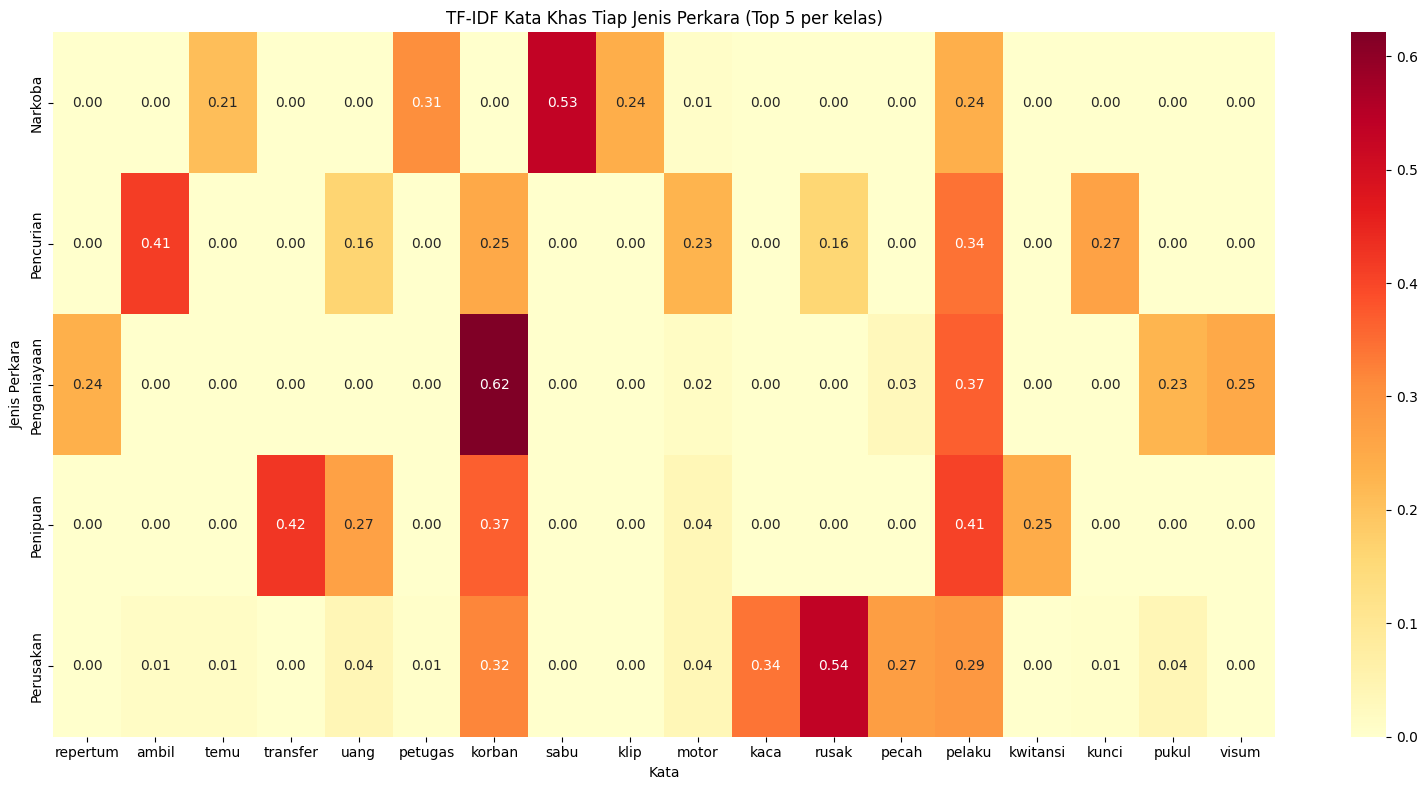

In [9]:
# ============================================================
# 8. HEATMAP KATA KHAS (5 kata teratas per kelas)
# ============================================================
selected_words = set()
for perkara in tfidf_class_df.index:
    top_words = tfidf_class_df.loc[perkara].sort_values(ascending=False).head(5)
    selected_words.update(top_words.index)

selected_words = list(selected_words)

heatmap_df = tfidf_class_df[selected_words]

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("TF-IDF Kata Khas Tiap Jenis Perkara (Top 5 per kelas)")
plt.ylabel("Jenis Perkara")
plt.xlabel("Kata")
plt.tight_layout()
plt.show()

# 9. MODELING CONTOH (Naive Bayes) - Bisa di-loop untuk semua split

In [10]:
# ============================================================
# 9. MODELING CONTOH (Naive Bayes) - Bisa di-loop untuk semua split
# ============================================================
print("\n" + "="*70)
print("TAHAP 9: PEMODELAN DENGAN NAIVE BAYES (CONTOH PADA SPLIT 80:20)")
print("="*70)

# Contoh: gunakan split 80:20 untuk modeling cepat
X_train = hasil_split['80_20']['X_train']
X_test = hasil_split['80_20']['X_test']
y_train = hasil_split['80_20']['y_train']
y_test = hasil_split['80_20']['y_test']

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = model.score(X_test, y_test)

print(f"Akurasi pada test set (split 80:20): {accuracy:.4f}")



TAHAP 9: PEMODELAN DENGAN NAIVE BAYES (CONTOH PADA SPLIT 80:20)
Akurasi pada test set (split 80:20): 0.9664


# 10. RINGKASAN AKHIR

In [11]:
# ============================================================
# 10. RINGKASAN AKHIR
# ============================================================
print("\n" + "="*70)
print("📊 RINGKASAN PROSES")
print("="*70)
print(f"Total sampel: {len(df)}")
print(f"Skenario split yang dicoba: {', '.join([f'{int((1-s)*100)}:{int(s*100)}' for s in SPLITS])}")
print(f"Jumlah fitur TF-IDF total (split 80:20): {hasil_split['80_20']['total_features']}")
print(f"Model accuracy (contoh 80:20): {accuracy:.4f}")
print("✅ Selesai!")


📊 RINGKASAN PROSES
Total sampel: 592
Skenario split yang dicoba: 60:40, 70:30, 80:20, 90:10
Jumlah fitur TF-IDF total (split 80:20): 1074
Model accuracy (contoh 80:20): 0.9664
✅ Selesai!


# Cara hitung TF-IDF

In [12]:
import pandas as pd
df_ = pd.read_csv('../data/processed/BB_MO_preprocessing_results.csv')
# Ambil 20 data pertama
df_20 = df_.head(20).copy()

# Tampilkan kolom yang digunakan
df_20 = df_20[['MO_final_text', 'BB_final_text']]

df_20.head()

,MO_final_text,BB_final_text
0,pelaku singgung tatap korban papas pukul wajah...,hasil visum repertum
1,pelaku pura pura tamu pembeli korban lengah pe...,hias emas
2,pelaku pura pura tamu pembeli korban lengah pe...,handphone
3,petugas curiga gerak gerik pelaku pinggir gele...,timbang digital
4,petugas curiga gerak gerik pelaku pinggir gele...,klip sabu


### 2. Menambahkan Kode Dokumen

In [13]:
df_20.insert(0, 'D', [f'D{i}' for i in range(len(df_20))])

df_20

,D,MO_final_text,BB_final_text
0,D0,pelaku singgung tatap korban papas pukul wajah...,hasil visum repertum
1,D1,pelaku pura pura tamu pembeli korban lengah pe...,hias emas
2,D2,pelaku pura pura tamu pembeli korban lengah pe...,handphone
3,D3,petugas curiga gerak gerik pelaku pinggir gele...,timbang digital
4,D4,petugas curiga gerak gerik pelaku pinggir gele...,klip sabu
5,D5,pelaku rusak kunci stang motor kunci motor par...,sepeda motor
6,D6,pelaku rusak halaman korban akibat sengketa tanah,NaN
7,D7,pelaku tawar sepeda motor lelang korban harga ...,NaN
8,D8,dasar informasi petugas gerebek raya galang da...,klip sabu
9,D9,pelaku tangkap tangan transaksi narkoba jenis ...,alat hisap bong


### 3. TF-IDF untuk Modus Operandi (MO)

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_mo = TfidfVectorizer()

X_mo = vectorizer_mo.fit_transform(df_20['MO_final_text'])

matriks

In [15]:
print(X_mo.shape)

(20, 105)


Artinya:

Terdapat 20 dokumen.
Terdapat 105 kata unik (vocabulary).

Dengan demikian, ukuran matriks TF-IDF adalah:

20×105

Baris menunjukkan dokumen, sedangkan kolom menunjukkan kata unik.

### 4. Menampilkan Vocabulary

In [16]:
vocab_mo = vectorizer_mo.get_feature_names_out()

vocab_df = pd.DataFrame({
    'No': range(1, len(vocab_mo)+1),
    'Kata': vocab_mo
})

vocab_df

,No,Kata
0,1,akibat
1,2,alas
2,3,ambil
3,4,bakau
4,5,bawa
...,...,...
100,101,turun
101,102,uang
102,103,uras
103,104,wajah


### 5. Menampilkan Matriks TF-IDF

In [17]:
tfidf_mo = pd.DataFrame(
    X_mo.toarray(),
    columns=vectorizer_mo.get_feature_names_out(),
    index=df_20['D']
).round(4)

tfidf_mo #semua data
# tfidf_mo.head() #hanya 5 data teratas

,akibat,alas,ambil,bakau,bawa,bayar,berat,biaya,cemburu,cepat,...,terlapor,timbang,transaksi,transfer,tua,turun,uang,uras,wajah,warung
D,,,,,,,,,,,,,,,,,,,,,
D0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3401,0.0000
D1,0.0000,0.0000,0.0000,0.0000,0.2712,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
D2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3163,0.0000,0.0000
D3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
D4,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
D5,0.0000,0.0000,0.0000,0.0000,0.2542,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
D6,0.4136,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
D7,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.3426,0.0000,0.0000,0.2489,0.0000,0.0000,0.0000
D8,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.3548,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


Interpretasi:

Nilai semakin besar menunjukkan kata semakin penting pada dokumen tersebut.
Nilai 0 menunjukkan kata tidak muncul pada dokumen.

### 6. Menghitung TF Secara Manual untuk D0

**0** adalah posisi dokumen ganti angka untuk mencoba ke dokumen lain dari 0-19

In [18]:
# inisialisasi dokumen yang akan dihitung
doc = df_20.loc[0, 'MO_final_text']

doc

'pelaku singgung tatap korban papas pukul wajah korban tangan kosong'

Pisahkan menjadi token

In [19]:
tokens = doc.split()

jumlah_kata = len(tokens)
jumlah_kata

10

hasil yang di dapat 10 karena terdapat 10 kata hasil berubah tergantung panjang token pada dokumen

### Hitung frekuensi kata.

In [20]:
from collections import Counter

tf_count = Counter(tokens)

tf_df = pd.DataFrame(
    tf_count.items(),
    columns=['kata', 'frekuensi']
)

tf_df['TF'] = tf_df['frekuensi'] / jumlah_kata

tf_df

,kata,frekuensi,TF
0,pelaku,1,0.1
1,singgung,1,0.1
2,tatap,1,0.1
3,korban,2,0.2
4,papas,1,0.1
5,pukul,1,0.1
6,wajah,1,0.1
7,tangan,1,0.1
8,kosong,1,0.1


| Kolom     | Penjelasan                    |
| --------- | ----------------------------- |
| kata      | Kata yang muncul pada dokumen |
| frekuensi | Jumlah kemunculan kata        |
| TF        | Nilai Term Frequency          |


Rumus *Term Frequency (TF)* adalah:

$$
TF(t,d)=\frac{f_{t,d}}{\sum_k f_{k,d}}
$$

dengan:

- $TF(t,d)$ = nilai TF kata ke-$t$ pada dokumen ke-$d$
- $f_{t,d}$ = jumlah kemunculan kata ke-$t$ pada dokumen ke-$d$
- $\sum_k f_{k,d}$ = jumlah seluruh kata pada dokumen ke-$d$

Sebagai contoh, digunakan dokumen D0 berikut.


pelaku singgung tatap **korban** papas pukul wajah **korban** tangan kosong

contoh untuk kata **"korban"**.

Kata **"korban"** muncul sebanyak 2 kali pada dokumen D0.

$$
TF(\text{korban}, D0)=\frac{2}{10}
$$

$$
TF(\text{korban}, D0)=0{,}2
$$

### 7. Menghitung df dan IDF Manual

**N** adalah jumlah dokumen yang ada

In [21]:
N = len(df_20)

print(N)

20


Output:
20

##### Hitung document frequency(df) pada kata "papas"

In [22]:
kata = 'papas'

df_term = df_20['MO_final_text'].apply(
    lambda x: kata in x.split()
).sum()

print(f"Hasil jumlah kata", kata ,"pada semua dokumen terdapat :", df_term, "kata")

Hasil jumlah kata papas pada semua dokumen terdapat : 1 kata


##### Hitung IDF

Rumus *Inverse Document Frequency (IDF)* adalah:

$$
IDF(t)=\log\left(\frac{1+N}{1+df(t)}\right)+1
$$

dengan:

- $IDF(t)$ = nilai IDF untuk kata ke-$t$
- $N$ = jumlah seluruh dokumen
- $df(t)$ = jumlah dokumen yang mengandung kata ke-$t$

Pada penelitian ini digunakan sebanyak:

$$
N = 20
$$

Sebagai contoh, akan dihitung nilai IDF untuk kata **"papas"**.

Kata **"papas"** muncul pada 1 dokumen, sehingga:

$$
df(\text{papas}) = 1
$$

Substitusi nilai ke dalam rumus IDF:

$$
IDF(\text{papas})=
\log\left(\frac{1+20}{1+1}\right)+1
$$

$$
IDF(\text{papas})=
\log\left(\frac{21}{2}\right)+1
$$

$$
IDF(\text{papas})=3{,}3514
$$

In [23]:
import numpy as np

idf = np.log((1 + N) / (1 + df_term)) + 1

print(f"Hasil IDF untuk kata {kata}: {idf:.4f}")

Hasil IDF untuk kata papas: 3.3514


### 8. Menghitung TF-IDF Manual
TF kata "papas" pada D0 bisa ganti dengan kata lain

nilai 1 karena hanya 1 kali muncul

In [24]:
tf = 1 / 10
print("Hasil tf untuk kata", kata, ":", tf)

Hasil tf untuk kata papas : 0.1


##### Hitung TF-IDF

Rumus TF-IDF adalah:

$$
TFIDF(t,d)=TF(t,d)\times IDF(t)
$$

Contoh perhitungan TF-IDF untuk kata **"papas"** pada dokumen D0:

$$
TFIDF(\text{papas}, D0)=0{,}1\times3{,}3514
$$

$$
TFIDF(\text{papas}, D0)=0{,}3351
$$

In [25]:
tfidf = tf * idf

print(f"Hasil tfidf dari kata {kata} : {tfidf:.4f}")

Hasil tfidf dari kata papas : 0.3351


### 9. Membuat Tabel Perhitungan Manual

In [26]:
contoh = ['papas', 'korban', 'papas']

hasil = []

for kata in contoh:

    tf = tf_count[kata] / jumlah_kata

    df_term = df_20['MO_final_text'].apply(
        lambda x: kata in x.split()
    ).sum()

    idf = np.log((1 + N) / (1 + df_term)) + 1

    hasil.append({
        'kata': kata,
        'TF': round(tf, 4),
        'df': df_term,
        'IDF': round(idf, 4),
        'TF-IDF': round(tf * idf, 4)
    })

hasil_df = pd.DataFrame(hasil)

print(hasil_df)

     kata   TF  df     IDF  TF-IDF
0   papas  0.1   1  3.3514  0.3351
1  korban  0.2  12  1.4796  0.2959
2   papas  0.1   1  3.3514  0.3351
